<a href="https://colab.research.google.com/github/praveenbunker/data-science-project/blob/main/Student%20Performance%20Prediction/Student_Performance_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
from google.colab import files

uploaded = files.upload()

Saving student_performance_dataset.csv to student_performance_dataset.csv


In [4]:
df = pd.read_csv("student_performance_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (500, 7)


,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Sleep_Hours,Final_Score,Performance
0,4.4,86.4,46.1,68.7,5.3,46.9,Fail
1,9.6,79.1,67.5,66.1,5.2,63.2,Pass
2,7.6,68.9,87.4,36.7,8.5,58.9,Pass
3,6.4,91.6,78.9,57.2,5.2,57.1,Pass
4,2.4,85.8,83.4,59.7,5.4,47.9,Fail


## Dataset **information**


In [5]:
print("Dataset Information:")
print(df.info())

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Study_Hours       500 non-null    float64
 1   Attendance        500 non-null    float64
 2   Previous_Marks    500 non-null    float64
 3   Assignment_Score  500 non-null    float64
 4   Sleep_Hours       500 non-null    float64
 5   Final_Score       500 non-null    float64
 6   Performance       500 non-null    object 
dtypes: float64(6), object(1)
memory usage: 27.5+ KB
None

Column Names:
['Study_Hours', 'Attendance', 'Previous_Marks', 'Assignment_Score', 'Sleep_Hours', 'Final_Score', 'Performance']


## Null values check

In [6]:
print("Null Values in Each Column:")
print(df.isnull().sum())

Null Values in Each Column:
Study_Hours         0
Attendance          0
Previous_Marks      0
Assignment_Score    0
Sleep_Hours         0
Final_Score         0
Performance         0
dtype: int64


## Basic statistics

In [7]:
df.describe()

,Study_Hours,Attendance,Previous_Marks,Assignment_Score,Sleep_Hours,Final_Score
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000
mean,5.488600,76.687200,66.053400,67.271000,6.500000,51.80280
std,2.690369,12.847254,17.832168,18.656599,1.428987,10.98964
min,1.000000,55.200000,35.300000,35.200000,4.000000,21.80000
25%,3.200000,65.300000,49.450000,50.675000,5.375000,44.47500
50%,5.600000,76.200000,67.400000,68.050000,6.500000,51.65000
75%,7.800000,87.725000,81.650000,82.900000,7.700000,58.95000
max,9.900000,100.000000,95.000000,99.900000,9.000000,80.00000


## ***Pass/Fail graph***

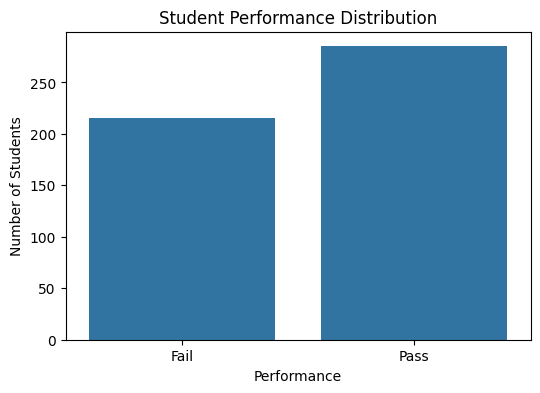

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Performance")

plt.title("Student Performance Distribution")
plt.xlabel("Performance")
plt.ylabel("Number of Students")

plt.show()

# **Study Hours vs Final Score**

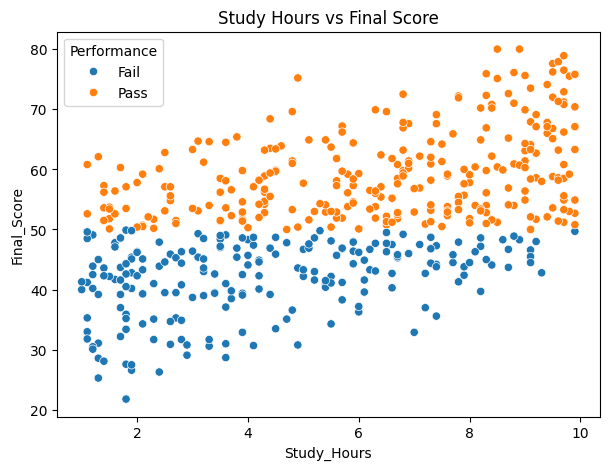

In [9]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Study_Hours",
    y="Final_Score",
    hue="Performance"
)

plt.title("Study Hours vs Final Score")
plt.show()

## ***Correlation Heatmap***

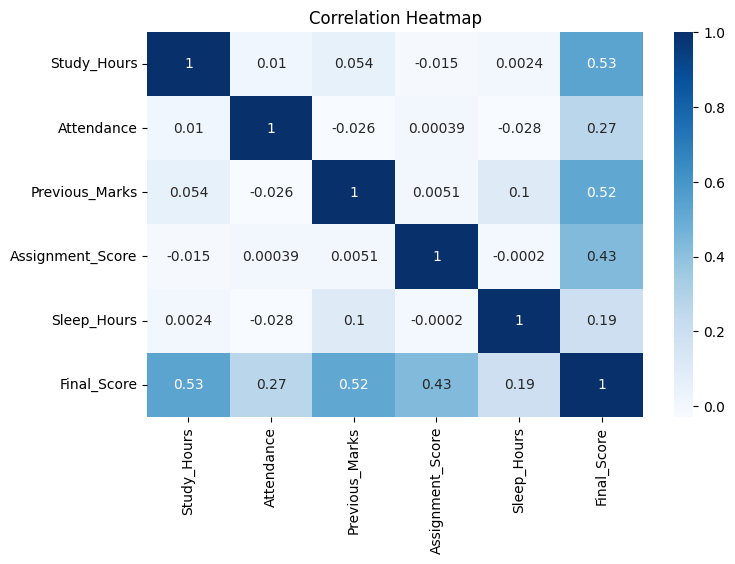

In [10]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")
plt.show()

# MACHINE LEARNING

---
## Features and Target


| Feature          | Meaning                        |
| ---------------- | ------------------------------ |
| Study_Hours      | Student kitne hours padhta hai |
| Attendance       | Attendance percentage          |
| Previous_Marks   | Previous exam marks            |
| Assignment_Score | Assignment performance         |
| Sleep_Hours      | Average sleep                  |
##

In [11]:
X = df[
    [
        "Study_Hours",
        "Attendance",
        "Previous_Marks",
        "Assignment_Score",
        "Sleep_Hours"
    ]
]

y = df["Performance"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Study_Hours  Attendance  Previous_Marks  Assignment_Score  Sleep_Hours
0          4.4        86.4            46.1              68.7          5.3
1          9.6        79.1            67.5              66.1          5.2
2          7.6        68.9            87.4              36.7          8.5
3          6.4        91.6            78.9              57.2          5.2
4          2.4        85.8            83.4              59.7          5.4

Target:
0    Fail
1    Pass
2    Pass
3    Pass
4    Fail
Name: Performance, dtype: object


# Train/Test Split



*  I divided the dataset into 80% training data and 20% testing data. The model learns from the training data and is evaluated on unseen testing data




In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (400, 5)
Testing Data: (100, 5)


# RANDOM FOREST MODEL

---
## Model training


In [13]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


## **Prediction**

In [14]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:20])

Predictions:
['Pass' 'Pass' 'Fail' 'Fail' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass' 'Fail'
 'Pass' 'Fail' 'Pass' 'Pass' 'Fail' 'Pass' 'Pass' 'Pass' 'Fail' 'Pass']


## **Accuracy**

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")

Random Forest Accuracy: 82.00%


## **Classification Report**

In [16]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

        Fail       0.84      0.72      0.78        43
        Pass       0.81      0.89      0.85        57

    accuracy                           0.82       100
   macro avg       0.82      0.81      0.81       100
weighted avg       0.82      0.82      0.82       100



## CONFUSION MATRIX

---
## The confusion matrix shows how many students were correctly and incorrectly classified as Pass or Fail


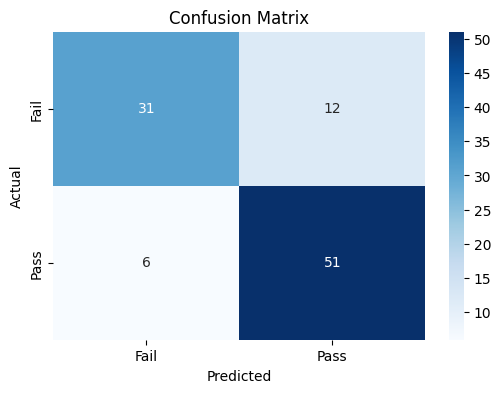

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Fail", "Pass"]
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# Check FEATURE IMPORTANCE

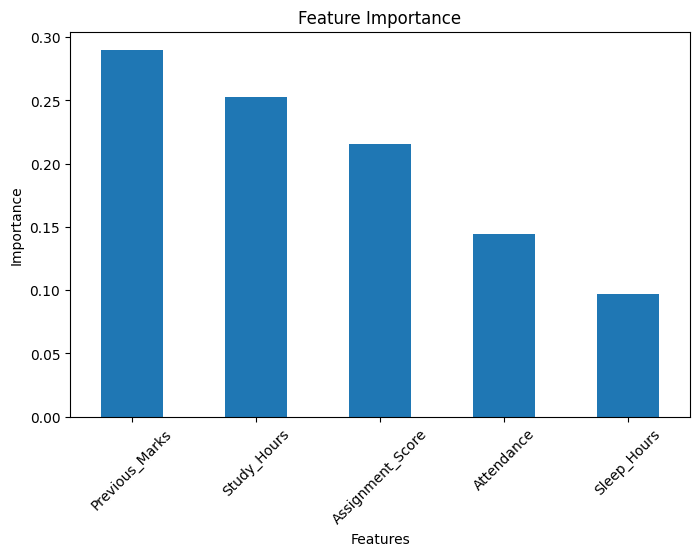

Previous_Marks      0.289787
Study_Hours         0.252737
Assignment_Score    0.215818
Attendance          0.144483
Sleep_Hours         0.097176
dtype: float64


In [18]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))

importance.plot(kind="bar")

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.show()

print(importance)

## NEW STUDENT KI PREDICTION

In [19]:
new_student = pd.DataFrame({
    "Study_Hours": [6],
    "Attendance": [85],
    "Previous_Marks": [72],
    "Assignment_Score": [80],
    "Sleep_Hours": [7]
})

prediction = model.predict(new_student)[0]

print("Student Details:")
print(new_student)

print("\nPredicted Performance:", prediction)

Student Details:
   Study_Hours  Attendance  Previous_Marks  Assignment_Score  Sleep_Hours
0            6          85              72                80            7

Predicted Performance: Pass


## SHOW THE CONFIDENCE

In [20]:
probability = model.predict_proba(new_student).max() * 100

print("Predicted Performance:", prediction)
print(f"Prediction Confidence: {probability:.2f}%")

Predicted Performance: Pass
Prediction Confidence: 97.00%


# Final conclusion

In [21]:
print("PROJECT CONCLUSION")
print("------------------")
print("The Student Performance Prediction system uses")
print("Machine Learning to predict whether a student will Pass or Fail.")
print()
print("Important factors include:")
print("- Study Hours")
print("- Attendance")
print("- Previous Marks")
print("- Assignment Score")
print("- Sleep Hours")
print()
print(f"Random Forest Accuracy: {accuracy * 100:.2f}%")

PROJECT CONCLUSION
------------------
The Student Performance Prediction system uses
Machine Learning to predict whether a student will Pass or Fail.

Important factors include:
- Study Hours
- Attendance
- Previous Marks
- Assignment Score
- Sleep Hours

Random Forest Accuracy: 82.00%
